In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.prompts import PromptTemplate
from langgraph.prebuilt import ToolNode, tools_condition
import os

c:\Users\jeste\OneDrive\Desktop\JES\TOOLS_Langchain\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(
    base_url="https://api.sambanova.ai/v1",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    model="DeepSeek-V3.1"
)

In [5]:
loader = PyPDFLoader("Langchain Notes.pdf")
docs = loader.load()

In [6]:
len(docs)

143

In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [8]:
len(chunks)

149

In [9]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(chunks, embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2384.50it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
vector_store.index_to_docstore_id

{0: 'fd4f03a5-9a73-44f3-b063-91384d068263',
 1: '2b8d281d-73e1-44dc-b82f-e64f88b0542d',
 2: 'facd776e-fa2c-4015-ae76-c867431db903',
 3: '5400ce41-ba7e-4ed8-861b-e61a17613033',
 4: 'e825638a-c7f0-41a8-97ee-9cdc641ae830',
 5: 'f335137c-d498-4266-a053-d788ee43ddc1',
 6: '7ddae36d-4f71-4184-8933-b40cd35557de',
 7: 'eefe11f4-6788-49be-a349-ff7a5bdf4d60',
 8: 'a8e130ca-8811-458e-9ef3-00a6b6da1e17',
 9: '13d9d2d4-c408-45ab-9c01-22d00cf2b45c',
 10: '466bbcb8-5e2d-4470-bbc1-07636f199f4d',
 11: '09b8ad52-5c37-4aff-a517-cab0b947201a',
 12: '2b8cd692-426c-4e36-86c3-80dece52579c',
 13: '3f452adb-2637-4f68-9adb-868b8a946134',
 14: '1a06a6a3-ea4a-45ac-8452-2017a1ad8626',
 15: '292a1a5f-06a2-4f62-b0cd-b73ecbb1208a',
 16: '5fcb0514-8165-4a9d-a4ab-ee003bf17271',
 17: 'c59eacd4-74da-4586-8ba1-74e0ed16f7b7',
 18: '9a4ca3cb-d9e8-4a96-9cb6-022ac48f3cd1',
 19: '3420ac52-9840-4288-a3a5-02c7df39014d',
 20: 'bbe1b410-bb9e-4dd5-86e9-bae81b7e2c9e',
 21: 'aaf2ac0a-df66-43d7-92d9-7a3457e0e196',
 22: '20c4096e-84a5-

In [10]:
retriever = vector_store.as_retriever(search_type= "similarity", search_kwargs= {"k": 4})

In [11]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [12]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [13]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [14]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [15]:
tool_node = ToolNode(tools)

In [16]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

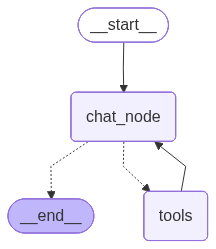

In [17]:
chatbot

In [18]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain the different types of tools usage in langchain"
                )
            )
        ]
    }
)

In [19]:
print(result['messages'][-1].content)

Based on the PDF notes, here are the different types of tools usage in LangChain:

## Types of Tools in LangChain

### 1. **BaseTool**
- The abstract base class for all tools in LangChain
- Defines the core structure and interface that any tool must follow
- All other tool types are built on top of BaseTool
- Provides the foundation for both simple one-liners and fully customized functions

### 2. **StructuredTool**
- A special type of tool where the input follows a structured schema
- Typically defined using a Pydantic model for input validation
- Ensures that tool inputs conform to a specific structure

### 3. **Built-in Tools**
- Pre-built, production-ready tools that LangChain provides
- Require minimal or no setup
- You don't have to write the function logic yourself - just import and use them
- Examples include various utility tools and integrations

### 4. **Custom Tools**
- Tools that you define yourself
- Created by writing Python functions and packaging them for LLM consumpti